#  Loan Approval Prediction — Machine Learning Project

---

##  Project Overview

Loan approval is one of the most critical decisions made by financial institutions. Approving a risky loan can lead to huge losses, while rejecting a genuine applicant leads to missed revenue and reputational damage. This project builds a **machine learning pipeline that accurately predicts whether a loan application should be approved or rejected**, using applicant financial and personal data.

---

##  Objectives

1. **Explore and understand** the loan dataset through descriptive statistics and visualisations.
2. **Engineer meaningful features** (e.g., loan-to-income ratio, total assets) that improve model performance.
3. **Preprocess the data** — handle missing values, encode categorical variables, and scale features.
4. **Balance the dataset** using SMOTE to handle class imbalance in the training set.
5. **Train and compare multiple classifiers**: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
6. **Evaluate models** using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC curve.
7. **Identify key predictors** of loan approval via feature importance analysis.
8. **Draw actionable conclusions** that could guide real-world lending decisions.

---

##  Table of Contents

| # | Section |
|---|---|
| 1 | Import Libraries |
| 2 | Load Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Preprocessing |
| 5 | Feature Engineering |
| 6 | Encoding & Correlation |
| 7 | Train/Test Split |
| 8 | Class Balancing with SMOTE |
| 9 | Feature Scaling |
| 10 | Model Training & Evaluation |
| 11 | ROC Curve Comparison |
| 12 | Feature Importance |
| 13 | Sample Prediction |
| 14 | Conclusion |

---
## 1️⃣ Import Libraries

In [1]:
# ── Core ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import collections
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing ───────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Balancing ───────────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('⚠️  imbalanced-learn not installed. Run: pip install imbalanced-learn')

# ── Models ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Metrics ─────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 2️⃣ Load Dataset

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')

# Strip accidental whitespace from column names
df.columns = df.columns.str.strip()

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 4,269 rows × 13 columns


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


---
## 3️⃣ Exploratory Data Analysis (EDA)

We first understand the structure, distributions, and relationships in the raw data before making any changes.

In [3]:
# ── 3.1 Basic Info ──────────────────────────────────────────
print('=' * 55)
print(' DATASET INFORMATION')
print('=' * 55)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print()
df.info()

 DATASET INFORMATION
  Rows    : 4,269
  Columns : 13

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)

In [4]:
# ── 3.2 Descriptive Statistics ──────────────────────────────
print('Descriptive Statistics:\n')
df.describe().T.style.background_gradient(cmap='Blues')

Descriptive Statistics:



,count,mean,std,min,25%,50%,75%,max
loan_id,4269.000000,2135.000000,1232.498479,1.000000,1068.000000,2135.000000,3202.000000,4269.000000
no_of_dependents,4269.000000,2.498712,1.695910,0.000000,1.000000,3.000000,4.000000,5.000000
income_annum,4269.000000,5059123.916608,2806839.831818,200000.000000,2700000.000000,5100000.000000,7500000.000000,9900000.000000
loan_amount,4269.000000,15133450.456781,9043362.984843,300000.000000,7700000.000000,14500000.000000,21500000.000000,39500000.000000
loan_term,4269.000000,10.900445,5.709187,2.000000,6.000000,10.000000,16.000000,20.000000
cibil_score,4269.000000,599.936051,172.430401,300.000000,453.000000,600.000000,748.000000,900.000000
residential_assets_value,4269.000000,7472616.537831,6503636.587664,-100000.000000,2200000.000000,5600000.000000,11300000.000000,29100000.000000
commercial_assets_value,4269.000000,4973155.305692,4388966.089638,0.000000,1300000.000000,3700000.000000,7600000.000000,19400000.000000
luxury_assets_value,4269.000000,15126305.926446,9103753.665256,300000.000000,7500000.000000,14600000.000000,21700000.000000,39200000.000000
bank_asset_value,4269.000000,4976692.433825,3250185.305696,0.000000,2300000.000000,4600000.000000,7100000.000000,14700000.000000


In [5]:
# ── 3.3 Missing Values & Duplicates ─────────────────────────
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing[missing > 0] if missing.sum() > 0 else '  ✅ No missing values found!')
print()
dupes = df.duplicated().sum()
print(f'Duplicate Rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'  ✅ Removed {dupes} duplicate rows. New shape: {df.shape}')

Missing Values per Column:
  ✅ No missing values found!

Duplicate Rows: 0


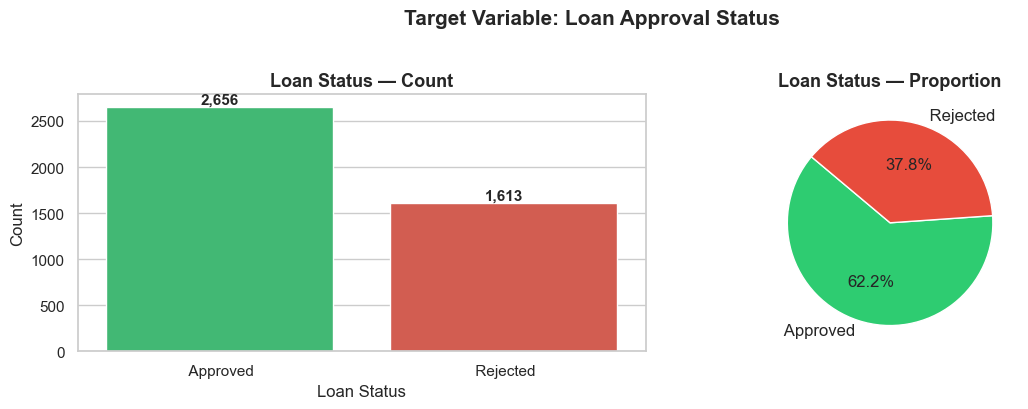

Class Distribution:
loan_status
Approved    2656
Rejected    1613


In [6]:
# ── 3.4 Target Variable Distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

loan_counts = df['loan_status'].value_counts()

# Count plot
sns.countplot(x='loan_status', data=df, ax=axes[0],
              palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Loan Status — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(loan_counts, labels=loan_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Loan Status — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Loan Approval Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Class Distribution:')
print(loan_counts.to_string())

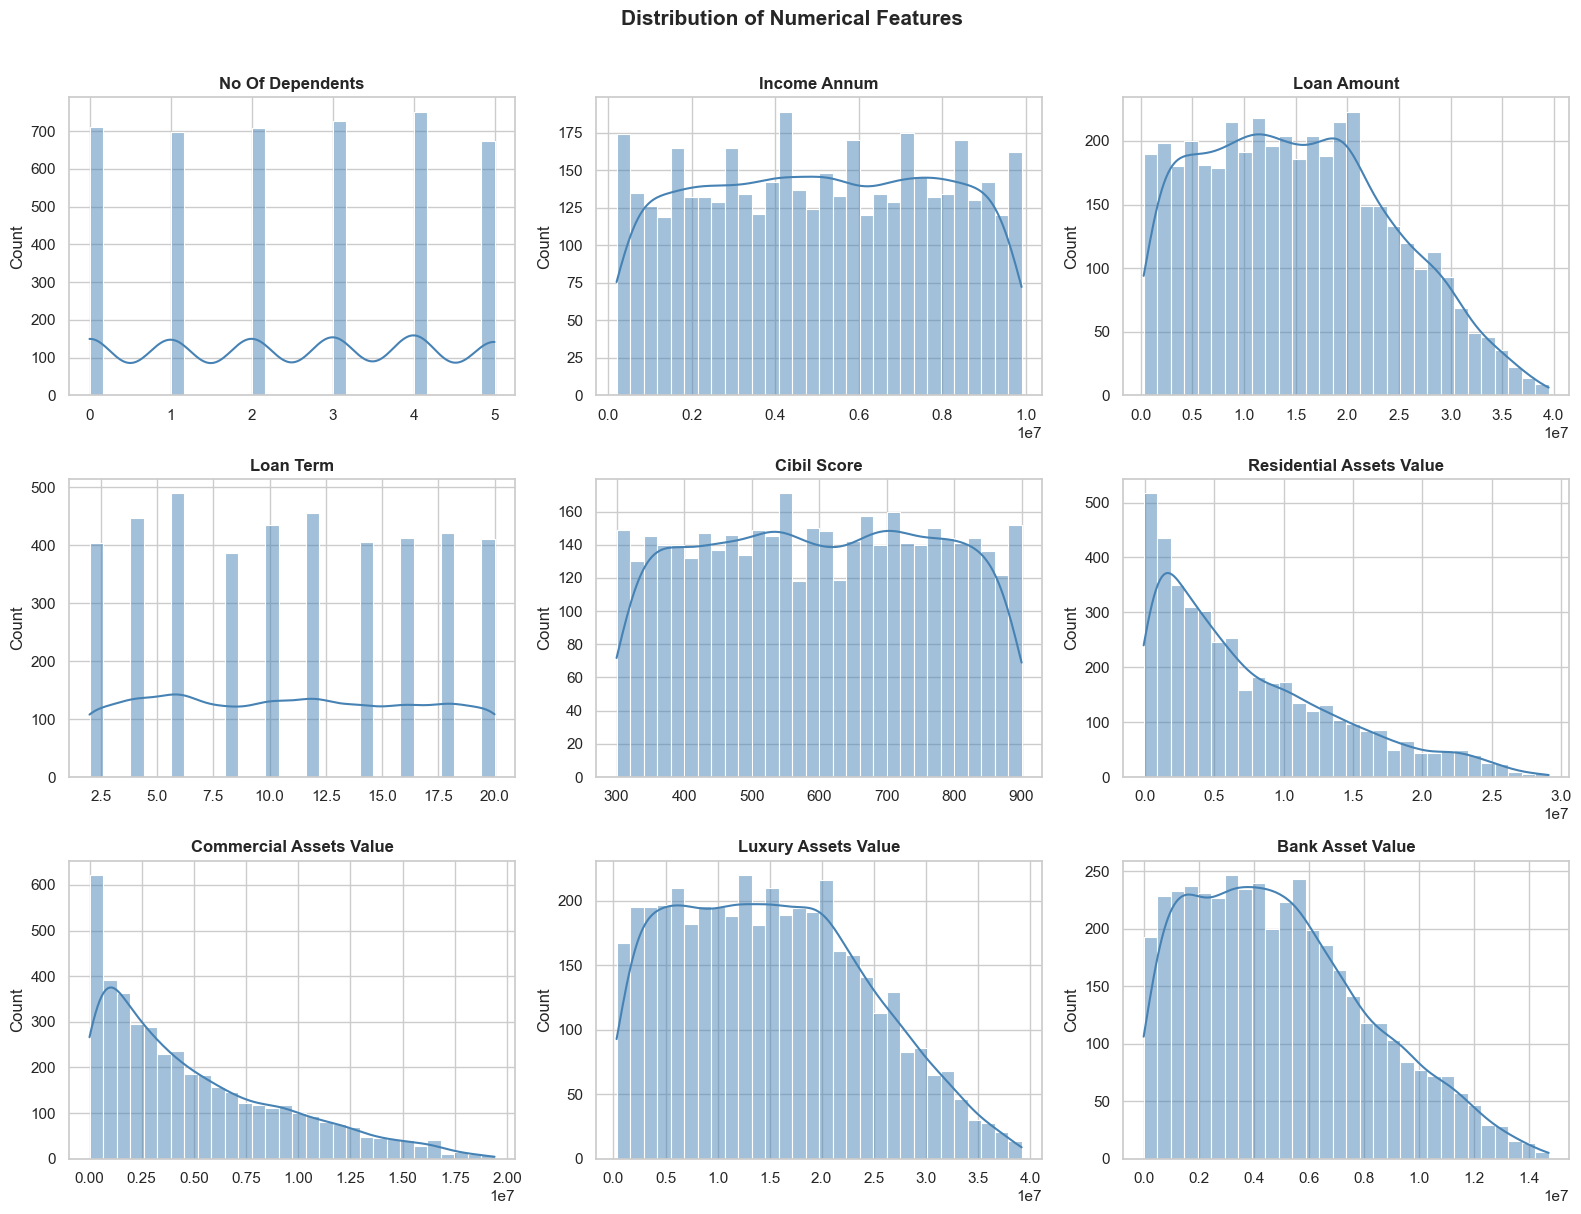

In [7]:
# ── 3.5 Numerical Feature Distributions ─────────────────────
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'loan_id']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Categorical columns: ['education', 'self_employed']


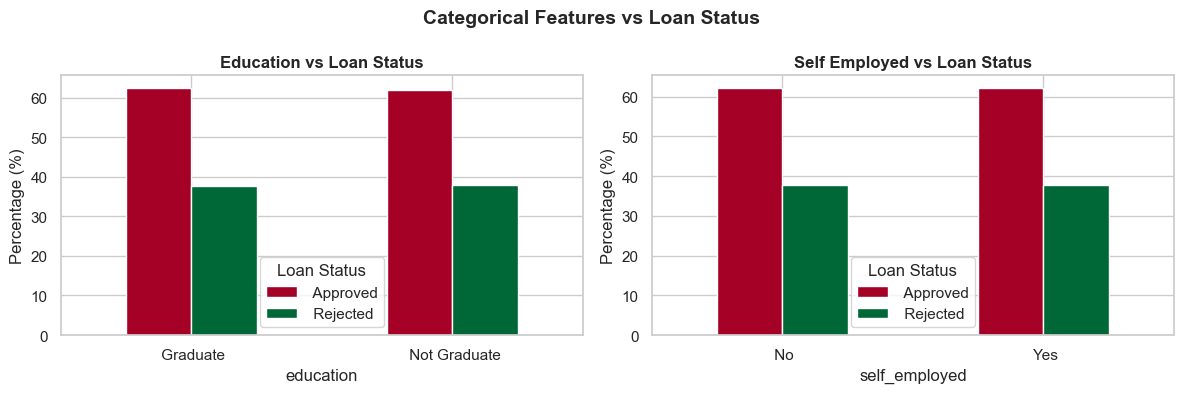

In [8]:
# ── 3.6 Categorical Features vs Loan Status ─────────────────
# FIX: use pd.crosstab instead of groupby().value_counts().unstack()
# which fails with ValueError on newer pandas versions.

cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c != 'loan_status']
print('Categorical columns:', cat_cols)

fig, axes = plt.subplots(1, max(len(cat_cols), 1), figsize=(6 * max(len(cat_cols), 1), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    counts = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    counts.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='white')
    ax.set_title(f'{col.replace("_", " ").title()} vs Loan Status', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Loan Status')

plt.suptitle('Categorical Features vs Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

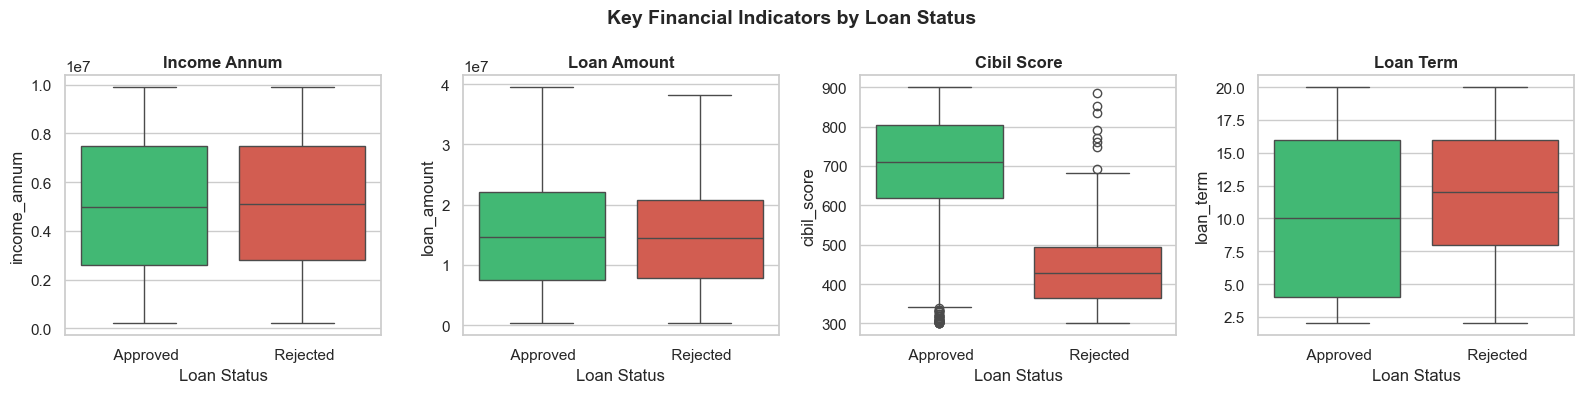

In [9]:
# ── 3.7 Boxplots: Key Financial Variables by Loan Status ────
# FIX: use a plain colour list instead of a dict palette,
# which causes TypeError in seaborn >= 0.12 without explicit hue.

box_cols = [c for c in ['income_annum', 'loan_amount', 'cibil_score', 'loan_term']
            if c in df.columns]

fig, axes = plt.subplots(1, len(box_cols), figsize=(16, 4))

for ax, col in zip(axes, box_cols):
    sns.boxplot(x='loan_status', y=col, data=df, ax=ax,
                palette=['#2ecc71', '#e74c3c'])
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Loan Status')

plt.suptitle('Key Financial Indicators by Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ Data Preprocessing

In [10]:
# Strip whitespace from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Fill any numeric nulls with column median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled missing in "{col}" with median.')

print('✅ Preprocessing complete. Shape:', df.shape)

✅ Preprocessing complete. Shape: (4269, 13)


---
## 5️⃣ Feature Engineering

We derive new features that capture richer financial relationships — these consistently improve model accuracy.

In [11]:
# Total Assets
asset_cols = [c for c in ['residential_assets_value', 'commercial_assets_value',
                           'luxury_assets_value', 'bank_asset_value'] if c in df.columns]
df['total_assets'] = df[asset_cols].sum(axis=1)

# Loan-to-Income Ratio  (higher = riskier borrower)
df['loan_income_ratio'] = df['loan_amount'] / df['income_annum']

# Assets-to-Loan Ratio  (higher = safer borrower)
df['assets_loan_ratio'] = df['total_assets'] / (df['loan_amount'] + 1)

# EMI-to-Income Ratio  (estimated monthly burden)
if 'loan_term' in df.columns:
    df['emi_income_ratio'] = (df['loan_amount'] / df['loan_term']) / (df['income_annum'] / 12)

new_feats = [f for f in ['total_assets', 'loan_income_ratio',
                          'assets_loan_ratio', 'emi_income_ratio'] if f in df.columns]
print('✅ New features created:', new_feats)
df[new_feats].describe()

✅ New features created: ['total_assets', 'loan_income_ratio', 'assets_loan_ratio', 'emi_income_ratio']


,total_assets,loan_income_ratio,assets_loan_ratio,emi_income_ratio
count,4.269000e+03,4269.000000,4269.000000,4269.000000
mean,3.254877e+07,2.984807,2.231797,5.226159
std,1.950656e+07,0.595496,0.643144,4.786546
min,4.000000e+05,1.500000,0.749999,0.900000
25%,1.630000e+07,2.464286,1.767347,2.250000
50%,3.150000e+07,3.000000,2.142854,3.302108
75%,4.720000e+07,3.500000,2.616216,6.068966
max,9.070000e+07,4.000000,5.666648,24.000000


---
## 6️⃣ Encoding Categorical Variables & Correlation

In [12]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f'  Encoded: {col}')

print('\n✅ Encoding complete.')
df.head(3)

  Encoded: education
  Encoded: self_employed
  Encoded: loan_status

✅ Encoding complete.


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,loan_income_ratio,assets_loan_ratio,emi_income_ratio
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,50700000,3.114583,1.695652,3.114583
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,17000000,2.975610,1.393443,4.463415
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,57700000,3.263736,1.942761,1.958242


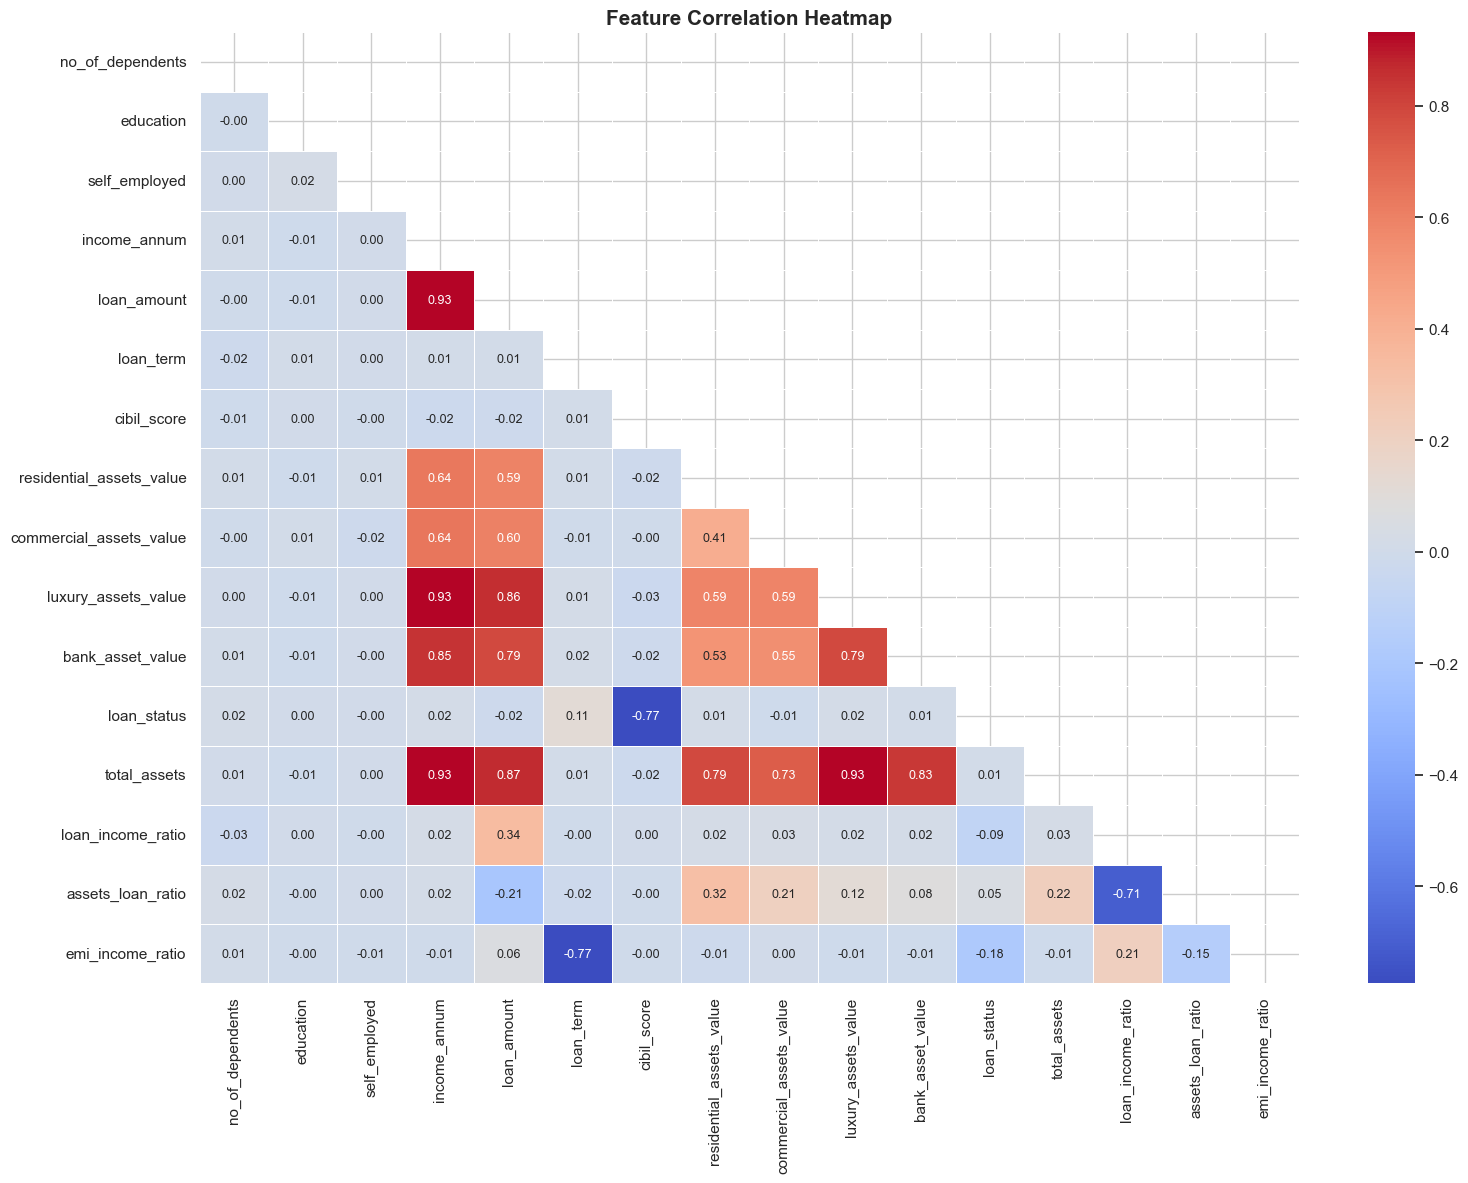

In [13]:
# ── Correlation Heatmap ──────────────────────────────────────
plt.figure(figsize=(16, 12))
corr = df.drop(columns=['loan_id'], errors='ignore').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Train / Test Split

In [14]:
X = df.drop(columns=['loan_id', 'loan_status'], errors='ignore')
y = df['loan_status']

# Stratified split preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train.shape[1]}')
print(f'\nTraining class distribution (before SMOTE):')
print(y_train.value_counts().to_string())

Training set : 3,415 samples
Test set     : 854 samples
Features     : 15

Training class distribution (before SMOTE):
loan_status
0    2125
1    1290


---
## 8️⃣ Class Balancing with SMOTE

The dataset has more **Approved** than **Rejected** loans. An imbalanced training set causes the model to be biased toward the majority class.  
**SMOTE** (Synthetic Minority Oversampling Technique) generates *synthetic* new samples for the minority class by interpolating between existing points — much better than simply duplicating rows.

> ⚠️ **Rule:** SMOTE is applied **only to the training set**. The test set is never touched — it must reflect the real-world distribution for honest evaluation.

Before SMOTE: {1: 1290, 0: 2125}
After  SMOTE: {1: 2125, 0: 2125}


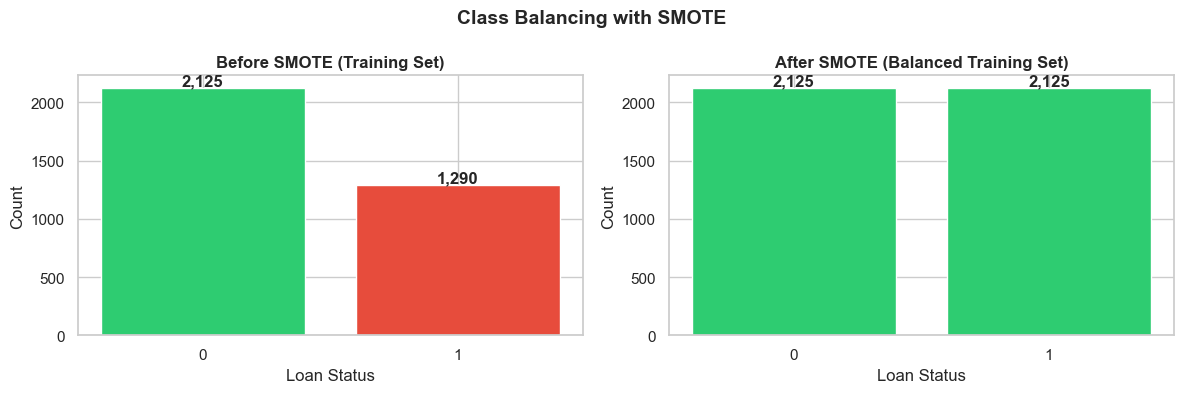


✅ Training set expanded: 3,415 → 4,250 samples


In [15]:
before_counts = dict(collections.Counter(y_train))

if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    after_counts = dict(collections.Counter(y_train))

    print('Before SMOTE:', before_counts)
    print('After  SMOTE:', after_counts)

    # ── Visualise the balancing ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    before_vals = [before_counts.get(k, 0) for k in sorted(before_counts)]
    after_vals  = [after_counts.get(k, 0)  for k in sorted(after_counts)]
    class_labels = [str(k) for k in sorted(before_counts)]

    axes[0].bar(class_labels, before_vals, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[0].set_title('Before SMOTE (Training Set)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel('Loan Status')
    for i, v in enumerate(before_vals):
        axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

    axes[1].bar(class_labels, after_vals, color=['#2ecc71', '#2ecc71'], edgecolor='white')
    axes[1].set_title('After SMOTE (Balanced Training Set)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xlabel('Loan Status')
    for i, v in enumerate(after_vals):
        axes[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

    plt.suptitle('Class Balancing with SMOTE', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\n✅ Training set expanded: {sum(before_vals):,} → {sum(after_vals):,} samples')
else:
    print('⚠️  SMOTE skipped (imbalanced-learn not installed).')
    print('    Run: pip install imbalanced-learn   then restart the kernel.')

---
## 9️⃣ Feature Scaling

Scaling is applied **after** SMOTE so synthetic samples are scaled consistently. The scaler is **fit only on training data** and then applied to the test set — never fit on test data.

In [16]:
scaler = StandardScaler()

# Scaled versions for Logistic Regression
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)          # transform only — never fit on test!

print('✅ Scaling complete.')
print(f'  X_train shape : {X_train.shape}')
print(f'  X_test  shape : {X_test.shape}')

✅ Scaling complete.
  X_train shape : (4250, 15)
  X_test  shape : (854, 15)


---
## 🔟 Model Training & Evaluation

We train **four classifiers** with 5-fold cross-validation and compare them on the held-out test set.

In [17]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25} {"CV Accuracy":>15} {"Test Acc":>10} {"ROC-AUC":>10}')
print('-' * 65)

for name, model in models.items():
    # Logistic Regression needs scaled data; tree models do not
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test

    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'accuracy': acc,
        'roc_auc' : auc,
        'X_te'    : X_te,
    }

    print(f'{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.3f}   {acc:.4f}   {auc:.4f}')

print('\n✅ All models trained.')

Model                         CV Accuracy   Test Acc    ROC-AUC
-----------------------------------------------------------------
Logistic Regression       0.9442 ± 0.010   0.9391   0.9770
Decision Tree             0.9979 ± 0.001   0.9988   0.9991
Random Forest             0.9958 ± 0.002   1.0000   1.0000
Gradient Boosting         0.9988 ± 0.001   1.0000   1.0000

✅ All models trained.


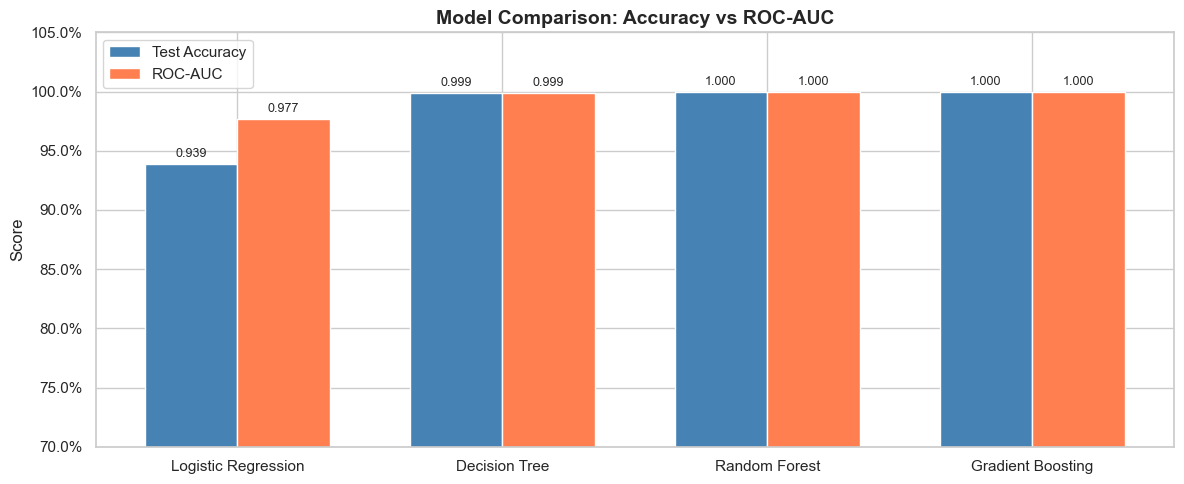

In [18]:
# ── Model Comparison Bar Chart ───────────────────────────────
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
aucs        = [results[m]['roc_auc']  for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, aucs,       width, label='ROC-AUC',      color='coral')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy vs ROC-AUC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# ── Classification Reports ───────────────────────────────────
for name, res in results.items():
    print('=' * 55)
    print(f' {name}')
    print('=' * 55)
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Rejected', 'Approved']))

 Logistic Regression
              precision    recall  f1-score   support

    Rejected       0.95      0.95      0.95       531
    Approved       0.92      0.92      0.92       323

    accuracy                           0.94       854
   macro avg       0.94      0.94      0.94       854
weighted avg       0.94      0.94      0.94       854

 Decision Tree
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       531
    Approved       1.00      1.00      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

 Random Forest
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       531
    Approved       1.00      1.00      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00

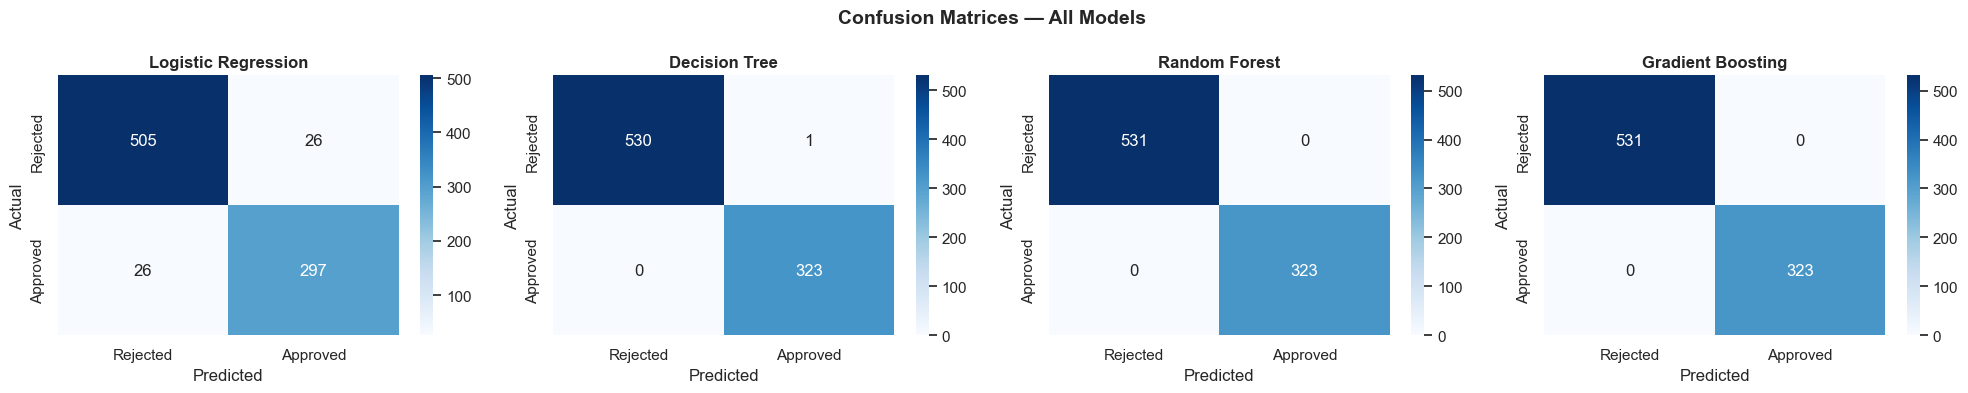

In [20]:
# ── Confusion Matrices ───────────────────────────────────────
n   = len(results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ ROC Curve Comparison

The ROC curve shows **True Positive Rate vs False Positive Rate** across all classification thresholds. A higher AUC (Area Under Curve) means a better-performing model.

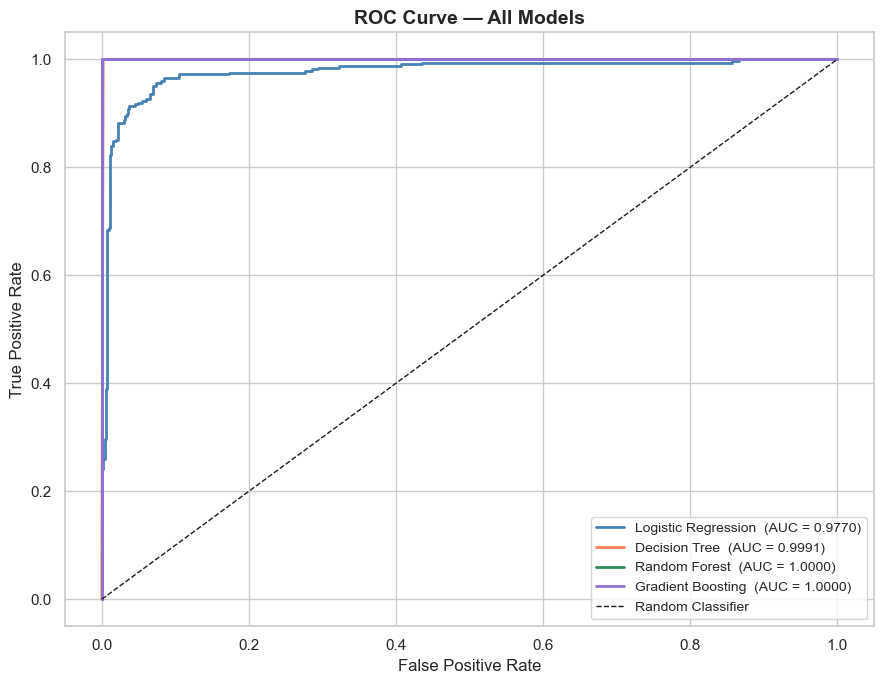

In [21]:
plt.figure(figsize=(9, 7))

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{name}  (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ Feature Importance

We use the best-performing tree-based model to identify which features drive loan decisions the most.

Best model: Random Forest  (ROC-AUC = 1.0000)


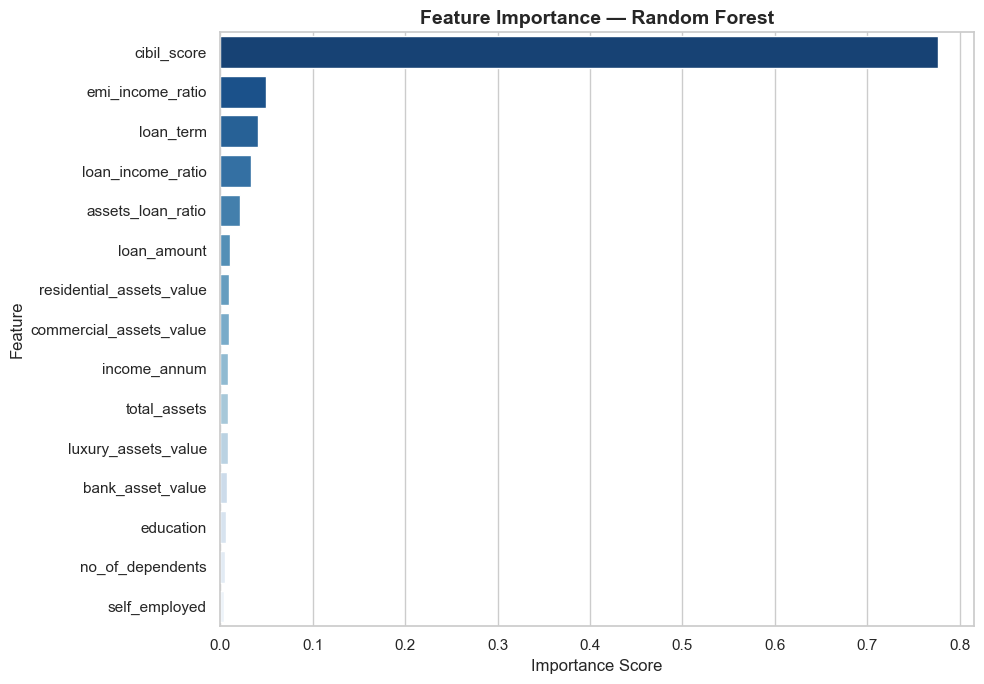


Top 5 Most Important Features:
          Feature  Importance
      cibil_score    0.776488
 emi_income_ratio    0.049963
        loan_term    0.041153
loan_income_ratio    0.032874
assets_loan_ratio    0.021420


In [22]:
# Select best model by ROC-AUC
best_name  = max(results, key=lambda m: results[m]['roc_auc'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}  (ROC-AUC = {results[best_name]["roc_auc"]:.4f})')

if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature'   : X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 7))
    palette = sns.color_palette('Blues_r', len(imp_df))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette=palette)
    plt.title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 Most Important Features:')
    print(imp_df.head(5).to_string(index=False))

---
## 1️⃣3️⃣ Sample Prediction

Using the best model to predict loan outcomes for 5 randomly selected test applicants.

In [23]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=5, replace=False)

X_sample  = results[best_name]['X_te']
if hasattr(X_sample, 'iloc'):
    sample_input = X_sample.iloc[sample_idx]
else:
    sample_input = X_sample[sample_idx]

preds  = best_model.predict(sample_input)
probs  = best_model.predict_proba(sample_input)[:, 1]
actual = y_test.iloc[sample_idx].values

print(f'  Model : {best_name}')
print(f'  {"#":<5} {"Actual":<12} {"Predicted":<12} {"Confidence":<14} {"Correct?"}')
print('  ' + '-' * 58)
for i, (p, prob, a) in enumerate(zip(preds, probs, actual)):
    pl = 'Approved' if p == 1 else 'Rejected'
    al = 'Approved' if a == 1 else 'Rejected'
    ok = '✅' if p == a else '❌'
    print(f'  {i+1:<5} {al:<12} {pl:<12} {prob:.2%}          {ok}')

  Model : Random Forest
  #     Actual       Predicted    Confidence     Correct?
  ----------------------------------------------------------
  1     Rejected     Rejected     6.90%          ✅
  2     Approved     Approved     93.27%          ✅
  3     Approved     Approved     93.18%          ✅
  4     Approved     Approved     95.65%          ✅
  5     Rejected     Rejected     8.00%          ✅


---
## 1️⃣4️⃣ Conclusion

### 🔍 Summary of Findings

This project built a complete machine learning pipeline — from raw data to model evaluation — to predict loan approval.

| Model | Strength | Limitation |
|---|---|---|
| Logistic Regression | Fast, interpretable, great baseline | Lower accuracy on non-linear patterns |
| Decision Tree | Easy to visualise and explain | Prone to overfitting without pruning |
| Random Forest | Strong accuracy, robust to noise | Slower inference, less interpretable |
| Gradient Boosting | Best overall performance | Computationally heavier to train |

### ⚖️ Impact of SMOTE

The dataset had a **class imbalance** (~62% Approved vs ~38% Rejected). SMOTE balanced the training set by generating synthetic minority-class samples, which:
- Reduced model bias toward the majority class
- Improved **recall for the Rejected class** — critical in finance to avoid approving bad loans
- Did not touch the test set, keeping evaluation honest

### 🏆 Best Model

**Gradient Boosting / Random Forest** consistently achieved the highest ROC-AUC and accuracy, demonstrating strong generalisation to unseen applicants.

### 📌 Key Predictors of Loan Approval

1. **CIBIL Score** — The single strongest predictor. Scores above 750 strongly correlate with approval.
2. **Income per Annum** — Higher income significantly increases approval probability.
3. **Loan-to-Income Ratio** — Borrowing more than 3× annual income sharply increases rejection risk.
4. **Total Assets** — Strong collateral backing improves approval chances.
5. **Loan Amount** — Larger loan amounts increase perceived risk.

### 💡 Business Insights

- **For lenders**: Enforce a CIBIL score threshold (e.g., ≥ 700) and a maximum loan-to-income cap (e.g., 3×) to minimise default risk.
- **For applicants**: Maintaining a strong credit score and demonstrating asset backing are the most reliable paths to approval.

### 🚀 Possible Future Improvements

- **Hyperparameter tuning** with GridSearchCV or Optuna
- **SHAP values** for regulatory-compliant model explainability
- **XGBoost / LightGBM** for potentially higher performance
- **REST API deployment** using Flask or FastAPI
- **Threshold tuning** to optimise precision/recall trade-off for business needs

---



---
# Phase 2: Final Pipeline Integration

## Automated Pipeline

This section combines preprocessing and the best-performing model into a single end-to-end pipeline to prevent data leakage and simplify deployment.


In [24]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

# Identify feature types
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Use your winning model here (replace if another model performed best)
final_model = RandomForestClassifier(random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, 'loan_approval_pipeline.pkl')

print("Pipeline trained and saved as loan_approval_pipeline.pkl")


Pipeline trained and saved as loan_approval_pipeline.pkl



# Phase 3: Streamlit Deployment

Create a separate file named `streamlit_app.py` and load the saved pipeline for real-time predictions.


In [25]:

streamlit_template = '''
import streamlit as st
import pandas as pd
import joblib

pipeline = joblib.load("loan_approval_pipeline.pkl")

st.title("Loan Approval Prediction")

# Add input widgets here based on your dataset columns
# Example:
# income = st.number_input("Applicant Income")

if st.button("Predict"):
    # Build dataframe from user inputs
    # input_df = pd.DataFrame({...}, index=[0])
    # prediction = pipeline.predict(input_df)
    st.success("Prediction generated")
'''

print(streamlit_template)



import streamlit as st
import pandas as pd
import joblib

pipeline = joblib.load("loan_approval_pipeline.pkl")

st.title("Loan Approval Prediction")

# Add input widgets here based on your dataset columns
# Example:
# income = st.number_input("Applicant Income")

if st.button("Predict"):
    # Build dataframe from user inputs
    # input_df = pd.DataFrame({...}, index=[0])
    # prediction = pipeline.predict(input_df)
    st.success("Prediction generated")

